In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import polars as pl

In [2]:
!kaggle competitions download -c int-20-h-2026-final-task
!unzip int-20-h-2026-final-task

int-20-h-2026-final-task.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  int-20-h-2026-final-task.zip
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [3]:
df = pl.read_csv('train_data_fixed.csv')
df = df.to_pandas()

categorical_features = [
    'transaction_type', 'merchant_token_type', 'traffic_source',
    'platform', 'token_type', 'ip_country', 'card_country',
    'cardbrand', 'cardtype', 'bank', 'payment_source',
    'acquiring_bank_id', 'mcc_id', 'card_pan_type', 'antifraud_decision'
] #'psp_id'

numerical_features = [
    'amount_scaled', #'card_exp_relative_scaled', 
    'settle_interval', 'cascade_number'
]

binary_features = ['is_subscription', 'is_secured'] #'is_payfac'

target = 'is_success'

features = categorical_features + numerical_features + binary_features

In [4]:
df[categorical_features] = df[categorical_features].fillna('unknown').astype(str)
df[numerical_features] = df[numerical_features].fillna(0)

for col in categorical_features:
    df[col] = df[col].astype('category') #for xgboost

train_df, test_df = train_test_split(df, test_size=0.1, shuffle=False)

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

In [5]:
model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=16,
    learning_rate=0.05,
    tree_method="hist",       
    enable_categorical=True,    
    device="cuda",              
    eval_metric="auc",
    early_stopping_rounds=50
)

In [6]:
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

[0]	validation_0-auc:0.84095
[100]	validation_0-auc:0.86988
[200]	validation_0-auc:0.87157
[300]	validation_0-auc:0.87272
[400]	validation_0-auc:0.87334
[499]	validation_0-auc:0.87370


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=50,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=16,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [7]:
y_pred = model.predict(X_test)

f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [08:32:05] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


F1 Score: 0.7517

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.81      0.82    346894
           1       0.75      0.75      0.75    253691

    accuracy                           0.79    600585
   macro avg       0.78      0.78      0.78    600585
weighted avg       0.79      0.79      0.79    600585



# Interpreting model results

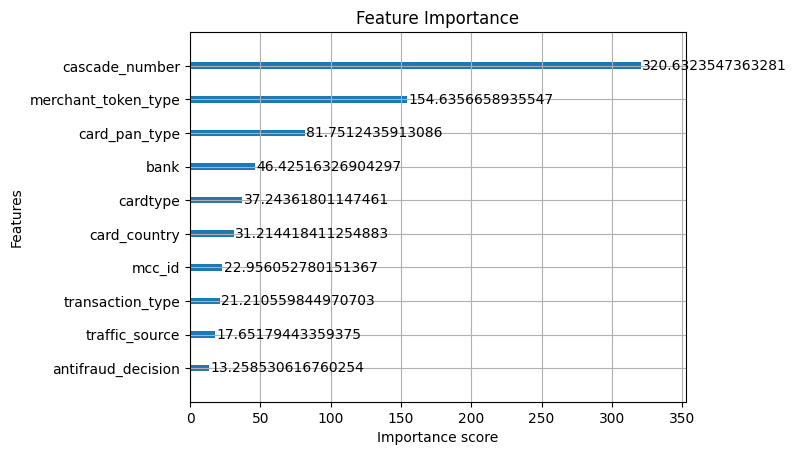

In [8]:
xgb.plot_importance(model, importance_type='gain', max_num_features=10)
plt.title("Feature Importance")
plt.show()

In [9]:
importance_gain = model.get_booster().get_score(importance_type='gain')

fi = pd.DataFrame(list(importance_gain.items()), columns=['Feature', 'Gain'])
fi = fi.sort_values('Gain', ascending=False)

print(fi.tail(10))

              Feature       Gain
19         is_secured  13.229929
11  acquiring_bank_id  11.057078
4          token_type  10.583651
3            platform   8.906701
10     payment_source   8.352870
18    is_subscription   8.095714
15      amount_scaled   7.352452
5          ip_country   6.411231
16    settle_interval   5.219296
7           cardbrand   4.812168


In [10]:
token_impact = df.groupby('merchant_token_type')['is_success'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

token_impact['approval_rate_%'] = (token_impact['mean'] * 100).round(2)
print(token_impact)

                         mean    count  approval_rate_%
merchant_token_type                                    
unknown              0.589259  1883967            58.93
1-click              0.553412   490998            55.34
retry                0.457269   359683            45.73
recurring            0.321503  3271201            32.15


/tmp/ipykernel_159/3134234451.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  token_impact = df.groupby('merchant_token_type')['is_success'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)


# Saving predictions

In [11]:
test = pd.read_csv('test.csv', usecols=features+['psp_order_id'])
test[categorical_features] = test[categorical_features].fillna('unknown').astype(str)
test[numerical_features] = test[numerical_features].fillna(0)

for col in categorical_features:
    test[col] = test[col].astype('category') #for xgboost

In [12]:
model_features = [
    'transaction_type', 'merchant_token_type', 'traffic_source', 
    'platform', 'token_type', 'ip_country', 'card_country', 
    'cardbrand', 'cardtype', 'bank', 'payment_source', 
    'acquiring_bank_id', 'mcc_id', 'card_pan_type', 'antifraud_decision',
    'amount_scaled', 'settle_interval', 
    'cascade_number', 'is_subscription', 'is_secured', 
]

X_inference = test[model_features]

test['is_success'] = model.predict(X_inference)

In [13]:
test[['psp_order_id', 'is_success']].to_csv('features_reduced.csv', index=False)